Behavioral analysis of introverts and extroverts

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
dataset = pd.read_csv("personality_dataset.csv")

In [ ]:
dataset.shape

(2900, 8)

In [ ]:
dataset.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


Data Cleaning

In [ ]:
dataset.isnull().sum()

,0
Time_spent_Alone,63
Stage_fear,73
Social_event_attendance,62
Going_outside,66
Drained_after_socializing,52
Friends_circle_size,77
Post_frequency,65
Personality,0


In [ ]:
df = dataset.dropna(subset=["Stage_fear", "Drained_after_socializing"])

In [ ]:
numerical_cols = df.select_dtypes(include=['float64', 'int64'])
numerical_cols.describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2718.000000,2717.000000,2714.000000,2703.000000,2712.000000
mean,4.508094,3.967979,2.998895,6.260821,3.567109
std,3.480495,2.898899,2.249544,4.294365,2.924968
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.000000,3.000000,5.000000,3.000000
75%,8.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


In [ ]:
df['Time_spent_Alone'] = df['Time_spent_Alone'].fillna(int(df['Time_spent_Alone'].median()))
df['Social_event_attendance'] = df['Social_event_attendance'].fillna(int(df['Social_event_attendance'].median()))
df['Going_outside'] = df['Going_outside'].fillna(int(df['Going_outside'].median()))
df['Friends_circle_size'] = df['Friends_circle_size'].fillna(int(df['Friends_circle_size'].median()))
df['Post_frequency'] = df['Post_frequency'].fillna(int(df['Post_frequency'].median()))

/tmp/ipykernel_715/1338646269.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Time_spent_Alone'] = df['Time_spent_Alone'].fillna(int(df['Time_spent_Alone'].median()))
/tmp/ipykernel_715/1338646269.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Social_event_attendance'] = df['Social_event_attendance'].fillna(int(df['Social_event_attendance'].median()))
/tmp/ipykernel_715/1338646269.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

In [ ]:
df.isnull().sum()

,0
Time_spent_Alone,0
Stage_fear,0
Social_event_attendance,0
Going_outside,0
Drained_after_socializing,0
Friends_circle_size,0
Post_frequency,0
Personality,0


In [ ]:
df['Stage_fear'] = df['Stage_fear'].replace({'Yes': True, 'No': False})
df['Drained_after_socializing'] = df['Drained_after_socializing'].replace({'Yes': True, 'No': False})

/tmp/ipykernel_715/3868418255.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Stage_fear'] = df['Stage_fear'].replace({'Yes': True, 'No': False})
/tmp/ipykernel_715/3868418255.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Stage_fear'] = df['Stage_fear'].replace({'Yes': True, 'No': False})
/tmp/ipykernel_715/3868418255.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False

In [ ]:
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,False,4.0,6.0,False,13.0,5.0,Extrovert
1,9.0,True,0.0,0.0,True,0.0,3.0,Introvert
2,9.0,True,1.0,2.0,True,5.0,2.0,Introvert
3,0.0,False,6.0,7.0,False,14.0,8.0,Extrovert
4,3.0,False,9.0,4.0,False,8.0,5.0,Extrovert


In [ ]:
df.shape

(2776, 8)

Training different models

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

In [ ]:
x = df.drop('Personality', axis=1)
y = df['Personality']

In [ ]:
le = LabelEncoder()
y = le.fit_transform(y)
#extrovert = 0

In [ ]:
y

array([0, 1, 1, ..., 1, 1, 0])

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Logistic regression

In [42]:
from sklearn.linear_model import LogisticRegression
params = {
    "C":[0.1,1,10,100],
    "solver":["lbfgs", "liblinear"]
}

lr = GridSearchCV(
    LogisticRegression(),
    params,
    cv=5,
    scoring='accuracy'
)

lr.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.1, 1, 10, 100],
                         'solver': ['lbfgs', 'liblinear']},
             scoring='accuracy')

In [44]:
y_pred_lr = lr.predict(x_test)

Random forest

In [43]:
from sklearn.ensemble import RandomForestClassifier
params = {
    "n_estimators":[100,200,300],
    "max_depth":[5,10,None],
    "min_samples_split":[2,5]
}

rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5,
    scoring='accuracy'
)

rf.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [45]:
y_pred_rf = rf.predict(x_test)

SVM

In [57]:
from sklearn.svm import SVC
params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm = GridSearchCV(
    SVC(),
    params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

svm.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [58]:
y_pred_svm = svm.predict(x_test)

Evaluation metrics

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [48]:
acc_lr = accuracy_score(y_test, y_pred_lr)
pre_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

In [49]:
acc_rf = accuracy_score(y_test, y_pred_rf)
pre_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

In [59]:
acc_svm = accuracy_score(y_test, y_pred_svm)
pre_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

Comparison

In [60]:
comp = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVM"],
    "Accuracy": [acc_lr, acc_rf, acc_svm],
    "Precision": [pre_lr, pre_rf, pre_svm],
    "Recall": [rec_lr, rec_rf, pre_svm],
    "F1 Score": [f1_lr, f1_rf, f1_svm]
})

In [61]:
comp

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.938849,0.919014,0.959559,0.938849
1,Random Forest,0.938849,0.919014,0.959559,0.938849
2,SVM,0.938849,0.919014,0.919014,0.938849


RF feature importance

In [63]:
imp = pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf.best_estimator_.feature_importances_
})

imp = imp.sort_values(
    by="Importance",
    ascending=False
)

In [64]:
imp

,Feature,Importance
1,Stage_fear,0.299536
4,Drained_after_socializing,0.241662
0,Time_spent_Alone,0.136329
2,Social_event_attendance,0.136191
6,Post_frequency,0.097276
3,Going_outside,0.080434
5,Friends_circle_size,0.008571


Confusion matrix

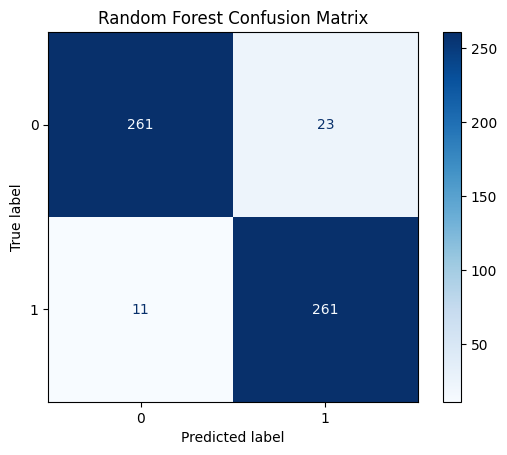

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf.best_estimator_,
    x_test,
    y_test,
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.show()